# Ablation Study: Hybrid FastKANAD + DeepSVDD With vs Without Attention

This notebook compares two hybrid models on **SWaT** for the ablation study:

- **FastKANAD + DeepSVDD**
- **Attention + FastKANAD + DeepSVDD**

The goal is to understand the **strengths and weaknesses** of each strategy and decide which variant to keep.

## Metrics included
- **Best F1**
- **Event F1**
- **5-delay F1**
- **AUPRC**
- **runtime**

## Reading guide
- For **paper-aligned MTS comparison**, **Best F1** is the most important metric.
- For **early/stable detection**, **Delay F1** is especially informative.
- **Event F1** reflects segment-level detection quality.
- **AUPRC** reflects ranking quality across thresholds.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = pd.DataFrame([
  {
    "Model": "FastKANAD + DeepSVDD",
    "Best F1": 0.9445027496746563,
    "Best F1 Precision": 0.9781961261711702,
    "Best F1 Recall": 0.9130531826390439,
    "Best F1 Threshold": 0.005716383457183838,
    "Event F1": 0.08791208791208752,
    "Event Precision": 0.06060606060606061,
    "Event Recall": 0.16,
    "Event Threshold": 0.013203144073486328,
    "Delay F1": 0.32857728299815364,
    "Delay Precision": 0.20165302223411816,
    "Delay Recall": 0.8866546273562892,
    "Delay Threshold": 0.0035185515880584717,
    "AUPRC": 0.9308137032531792,
    "Train+Valid Time (s)": 1915.303283195,
    "Test Time (s)": 18.525563562000116
  },
  {
    "Model": "Attention + FastKANAD + DeepSVDD",
    "Best F1": 0.9259748633764251,
    "Best F1 Precision": 0.9664607237422771,
    "Best F1 Recall": 0.8887445975285595,
    "Best F1 Threshold": 0.004161655902862549,
    "Event F1": 0.08219178082191736,
    "Event Precision": 0.0625,
    "Event Recall": 0.12,
    "Event Threshold": 0.006615102291107178,
    "Delay F1": 0.7387940675014202,
    "Delay Precision": 0.6737723830064704,
    "Delay Recall": 0.8177059026439137,
    "Delay Threshold": 0.002732604742050171,
    "AUPRC": 0.9470044900793507,
    "Train+Valid Time (s)": 2422.613046231,
    "Test Time (s)": 48.527225716999965
  }
])
results


,Model,Best F1,Best F1 Precision,Best F1 Recall,Best F1 Threshold,Event F1,Event Precision,Event Recall,Event Threshold,Delay F1,Delay Precision,Delay Recall,Delay Threshold,AUPRC,Train+Valid Time (s),Test Time (s)
0,FastKANAD + DeepSVDD,0.944503,0.978196,0.913053,0.005716,0.087912,0.060606,0.16,0.013203,0.328577,0.201653,0.886655,0.003519,0.930814,1915.303283,18.525564
1,Attention + FastKANAD + DeepSVDD,0.925975,0.966461,0.888745,0.004162,0.082192,0.062500,0.12,0.006615,0.738794,0.673772,0.817706,0.002733,0.947004,2422.613046,48.527226


## Compact comparison table

In [ ]:
summary = results[[
    "Model",
    "Best F1",
    "Event F1",
    "Delay F1",
    "AUPRC",
    "Train+Valid Time (s)",
    "Test Time (s)"
]].copy()

summary["Train+Valid Time (min)"] = summary["Train+Valid Time (s)"] / 60.0
summary


,Model,Best F1,Event F1,Delay F1,AUPRC,Train+Valid Time (s),Test Time (s),Train+Valid Time (min)
0,FastKANAD + DeepSVDD,0.944503,0.087912,0.328577,0.930814,1915.303283,18.525564,31.921721
1,Attention + FastKANAD + DeepSVDD,0.925975,0.082192,0.738794,0.947004,2422.613046,48.527226,40.376884


## Absolute metric differences

This table shows how the attention version changes each metric relative to the baseline without attention.


In [ ]:
base = results.iloc[0]
attn = results.iloc[1]

diff = pd.DataFrame({
    "Metric": ["Best F1", "Event F1", "Delay F1", "AUPRC", "Train+Valid Time (s)", "Test Time (s)"],
    "Without Attention": [
        base["Best F1"], base["Event F1"], base["Delay F1"], base["AUPRC"],
        base["Train+Valid Time (s)"], base["Test Time (s)"]
    ],
    "With Attention": [
        attn["Best F1"], attn["Event F1"], attn["Delay F1"], attn["AUPRC"],
        attn["Train+Valid Time (s)"], attn["Test Time (s)"]
    ],
})
diff["Absolute Change"] = diff["With Attention"] - diff["Without Attention"]
diff["Relative Change %"] = 100.0 * diff["Absolute Change"] / diff["Without Attention"]
diff


,Metric,Without Attention,With Attention,Absolute Change,Relative Change %
0,Best F1,0.944503,0.925975,-0.018528,-1.961655
1,Event F1,0.087912,0.082192,-0.005720,-6.506849
2,Delay F1,0.328577,0.738794,0.410217,124.846362
3,AUPRC,0.930814,0.947004,0.016191,1.739423
4,Train+Valid Time (s),1915.303283,2422.613046,507.309763,26.487177
5,Test Time (s),18.525564,48.527226,30.001662,161.947366


## Main performance plot

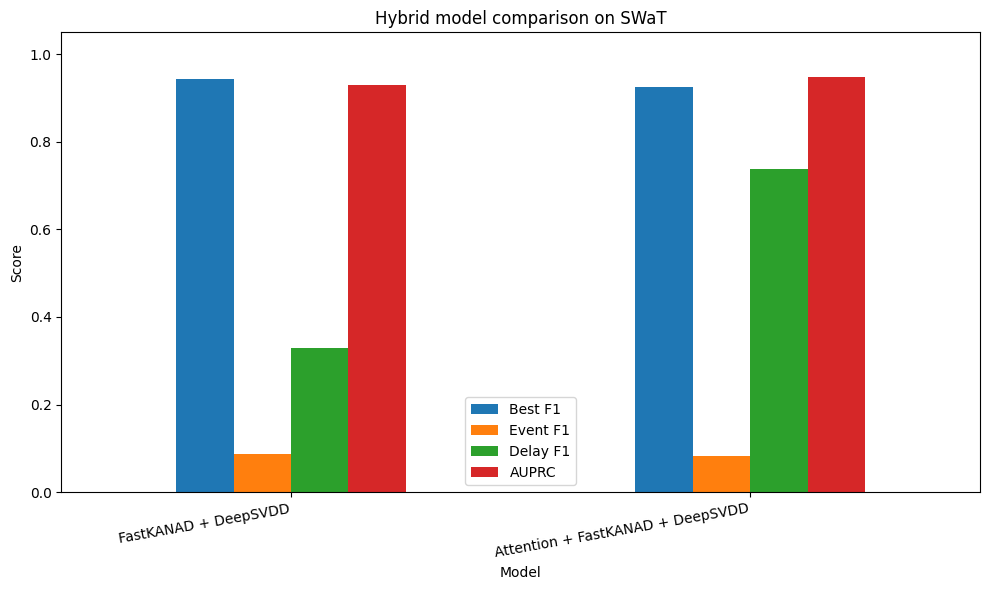

In [ ]:
metric_cols = ["Best F1", "Event F1", "Delay F1", "AUPRC"]
plot_df = results.set_index("Model")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Hybrid model comparison on SWaT")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()


## Focus on Best F1 and Delay F1

These two plots help highlight the main trade-off:
- **Best F1** favors the version **without attention**
- **Delay F1** strongly favors the version **with attention**


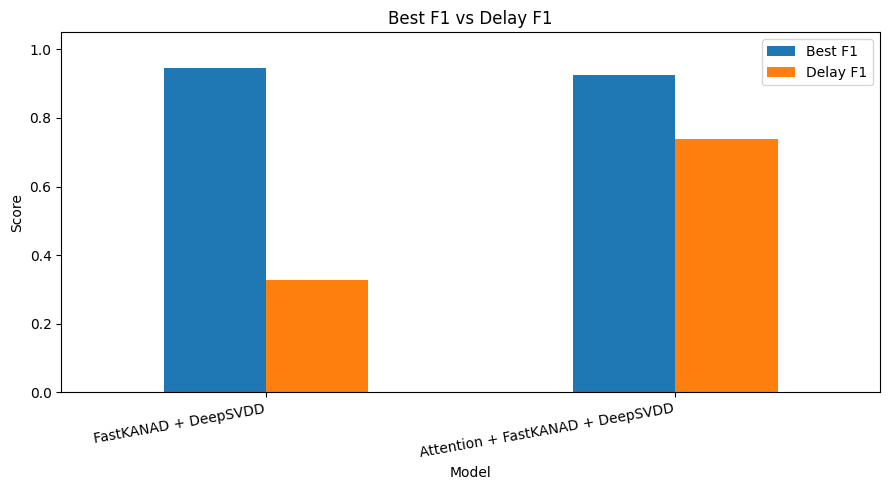

In [ ]:
best_delay = results.set_index("Model")[["Best F1", "Delay F1"]]
ax = best_delay.plot(kind="bar", figsize=(9, 5))
ax.set_title("Best F1 vs Delay F1")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()


## Precision / recall breakdown

In [ ]:
pr = results[[
    "Model",
    "Best F1 Precision", "Best F1 Recall",
    "Event Precision", "Event Recall",
    "Delay Precision", "Delay Recall"
]].copy()
pr


,Model,Best F1 Precision,Best F1 Recall,Event Precision,Event Recall,Delay Precision,Delay Recall
0,FastKANAD + DeepSVDD,0.978196,0.913053,0.060606,0.16,0.201653,0.886655
1,Attention + FastKANAD + DeepSVDD,0.966461,0.888745,0.062500,0.12,0.673772,0.817706


## Runtime comparison

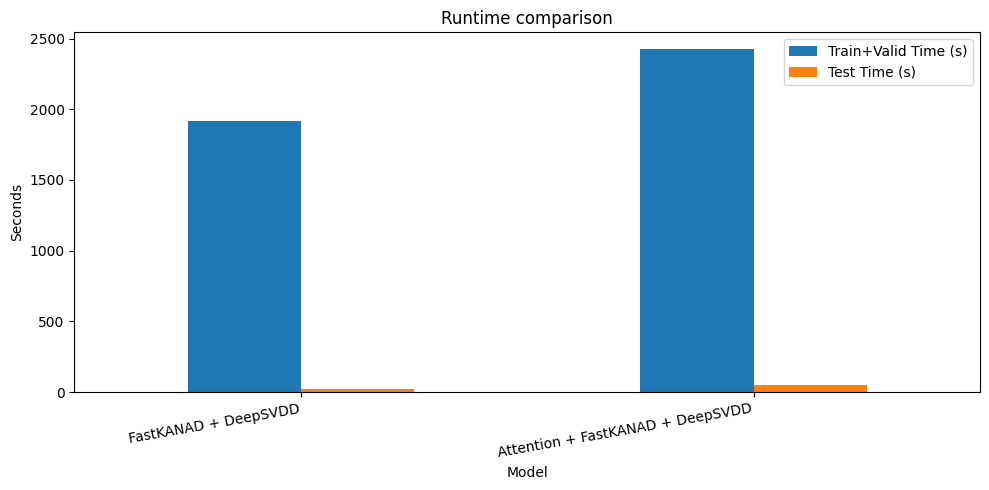

In [ ]:
runtime = results.set_index("Model")[["Train+Valid Time (s)", "Test Time (s)"]]
ax = runtime.plot(kind="bar", figsize=(10, 5))
ax.set_title("Runtime comparison")
ax.set_ylabel("Seconds")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()


## Threshold comparison

In [ ]:
thresholds = results[[
    "Model",
    "Best F1 Threshold",
    "Event Threshold",
    "Delay Threshold"
]].copy()
thresholds


,Model,Best F1 Threshold,Event Threshold,Delay Threshold
0,FastKANAD + DeepSVDD,0.005716,0.013203,0.003519
1,Attention + FastKANAD + DeepSVDD,0.004162,0.006615,0.002733


## Interpretation

### 1. Best F1
- **Without attention** is better: **0.9445 vs 0.9260**
- Since **Best F1** is the main metric used for **MTS comparison** in the official KAN-AD paper, this favors the **non-attention hybrid**.

### 2. Event F1
- Both versions are weak on event-level detection.
- **Without attention** is slightly better: **0.0879 vs 0.0822**
- So attention does **not** solve event fragmentation here.

### 3. Delay F1
- **With attention** is dramatically better: **0.7388 vs 0.3286**
- This suggests attention improves **temporal consistency / earlier useful detection**.

### 4. AUPRC
- **With attention** is better: **0.9470 vs 0.9308**
- This suggests attention improves **ranking quality**.

### 5. Runtime cost
- Attention is more expensive:
  - train+valid: **2422.6 s vs 1915.3 s**
  - test: **48.5 s vs 18.5 s**
- So the gain in Delay F1 and AUPRC comes with a clear computational cost.

## Overall trade-off
- **Without attention**:
  - strongest **Best F1**
  - slightly better **Event F1**
  - faster
- **With attention**:
  - much stronger **Delay F1**
  - better **AUPRC**
  - slower


## Decision guidance

### Choose **FastKANAD + DeepSVDD without attention** if:
- you want the **best paper-aligned MTS metric**
- you want the strongest **Best F1**
- you want the cheaper and simpler model

### Choose **Attention + FastKANAD + DeepSVDD** if:
- you care more about **delay-sensitive detection**
- you value better **ranking quality**
- you accept a higher runtime cost

## Practical recommendation for the thesis
A reasonable conclusion is:

> The attention layer does **not** improve the main MTS comparison metric (**Best F1**), but it **substantially improves Delay F1 and AUPRC**, revealing a trade-off between sharp point-wise separation and temporally smoother detection.

That makes the attention model a useful **ablation / extension**, while the **non-attention hybrid** remains the strongest main model if Best F1 is the primary selection criterion.


In [ ]:
summary.to_csv("ablation_hybrid_attention_summary.csv", index=False)
diff.to_csv("ablation_hybrid_attention_differences.csv", index=False)
pr.to_csv("ablation_hybrid_attention_precision_recall.csv", index=False)
thresholds.to_csv("ablation_hybrid_attention_thresholds.csv", index=False)

print("Saved CSV files:")
print("- ablation_hybrid_attention_summary.csv")
print("- ablation_hybrid_attention_differences.csv")
print("- ablation_hybrid_attention_precision_recall.csv")
print("- ablation_hybrid_attention_thresholds.csv")


Saved CSV files:
- ablation_hybrid_attention_summary.csv
- ablation_hybrid_attention_differences.csv
- ablation_hybrid_attention_precision_recall.csv
- ablation_hybrid_attention_thresholds.csv
